In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("weather.csv")

In [3]:
df.head(10)

,date,temperature,humidity,wind_speed,precipitation
0,2025-01-01,32,56,23,3
1,2025-01-02,34,43,22,6
2,2025-01-03,39,40,17,27
3,2025-01-04,17,50,24,0
4,2025-01-05,15,65,6,19
5,2025-01-06,42,35,20,18
6,2025-01-07,19,48,23,13
7,2025-01-08,25,52,17,2
8,2025-01-09,17,65,23,22
9,2025-01-10,42,86,7,8


In [4]:
df['date']=pd.to_datetime(df['date'])
df.set_index('date',inplace=True)

In [5]:
df.head(10)

,temperature,humidity,wind_speed,precipitation
date,,,,
2025-01-01,32,56,23,3
2025-01-02,34,43,22,6
2025-01-03,39,40,17,27
2025-01-04,17,50,24,0
2025-01-05,15,65,6,19
2025-01-06,42,35,20,18
2025-01-07,19,48,23,13
2025-01-08,25,52,17,2
2025-01-09,17,65,23,22


In [6]:
df['month']=df.index.month
df['day']=df.index.day
df['day_of_week']=df.index.dayofweek

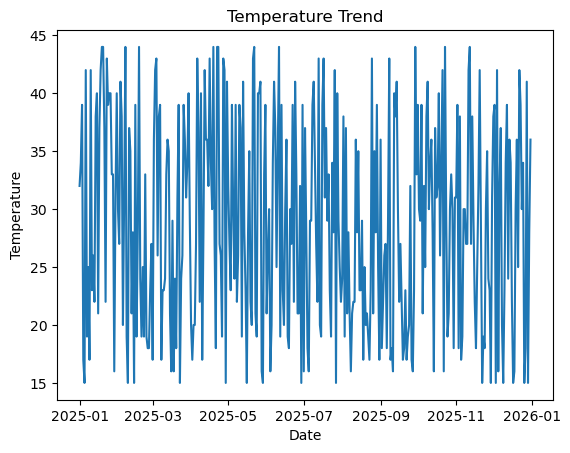

In [7]:
plt.figure()
plt.plot(df.index,df['temperature'])
plt.title("Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X=df[['humidity','wind_speed','precipitation','month','day']]
Y=df['temperature']

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2, shuffle=False)

In [9]:
from sklearn.ensemble import RandomForestRegressor
model= RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train,Y_train)

RandomForestRegressor(random_state=42)

In [10]:
predictions = model.predict(X_test)
print(predictions[:5])

[26.67 30.22 25.42 28.95 29.45]


In [12]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(Y_test, predictions)


In [13]:
print("MAE Error:",error)

MAE Error: 7.251643835616439


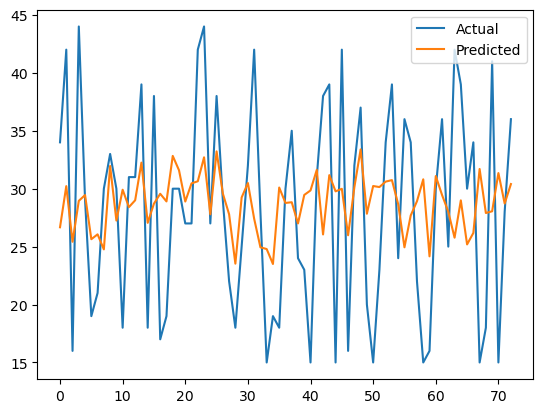

In [14]:
plt.figure()
plt.plot(Y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()

In [15]:
future_days = 7
last_row = df.iloc[-1]
future_data=[]
for i in range(future_days):
    new_row={
        'humidity': last_row['humidity'],
        'wind_speed':last_row['wind_speed'],
        'precipitation':last_row['precipitation'],
         'month': (last_row.name + pd.Timedelta(days=i+1)).month,
        'day': (last_row.name + pd.Timedelta(days=i+1)).day
    }
    future_data.append(new_row)

future_df = pd.DataFrame(future_data)

future_predictions = model.predict(future_df)

print("Next 7 days temperature prediction:")
print(future_predictions)

Next 7 days temperature prediction:
[29.39 31.01 31.55 32.24 30.58 31.81 32.25]
